# はじめに

このノートでは、PyTorch Geometricを利用してグラフニューラルネットワークを構築することを目指す。最初はPyTorchの基礎からはじめ、グラフニューラルネットワーク、PyTorch Geometricと内容を進めていく。
まずはPyTorchの基礎から始める。参考にしているサイトは下記の通り。

- [グラフニューラルネットワーク | 佐藤 竜馬](https://www.amazon.co.jp/%E3%82%B0%E3%83%A9%E3%83%95%E3%83%8B%E3%83%A5%E3%83%BC%E3%83%A9%E3%83%AB%E3%83%8D%E3%83%83%E3%83%88%E3%83%AF%E3%83%BC%E3%82%AF-%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92%E3%83%97%E3%83%AD%E3%83%95%E3%82%A7%E3%83%83%E3%82%B7%E3%83%A7%E3%83%8A%E3%83%AB%E3%82%B7%E3%83%AA%E3%83%BC%E3%82%BA-%E4%BD%90%E8%97%A4-%E7%AB%9C%E9%A6%AC/dp/4065347823)
- [グラフ深層学習のすゝめ。 - YouTube](https://www.youtube.com/watch?v=7rgXi3Xp6NI)
- [GCN — グラフ道場](https://yuya-s.github.io/GraphDojo/01GCN.html)
- [Tutorial 6: Basics of Graph Neural Networks](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/06-graph-neural-networks.html)
- [Static and Dynamic Attention: Implications for Graph Neural Networks](https://medium.com/data-science/static-and-dynamic-attention-implications-for-graph-neural-networks-eda0d9d7b60a)
- [Understanding Convolutions on Graphs](https://distill.pub/2021/understanding-gnns/)
- [A Gentle Introduction to Graph Neural Networks](https://distill.pub/2021/gnn-intro/)

## Tensor

PyTorchのtensorは多次元配列のこと。Numpyの配列みたいなもので、ベクトルは1次のtensor、行列は2次のtensorといえる。tensorの生成からはじめ、tensorの演算、テンソルの連結、テンソルの演算を行う。

In [1]:
import torch

torch.manual_seed(1989)

- `torch.Tensor`:指定したリスト要素からテンソルを作成
- `torch.zeros`: ゼロで埋められたテンソルを作成
- `torch.ones`:1で満たされたテンソルを作成
- `torch.rand`:0から1の間で均一にサンプリングされたランダム値を持つテンソルを作成
- `torch.randn`: 平均0、分散1の正規分布からサンプリングされたランダム値を持つテンソルを作成
- `torch.arange`: 数値列のテンソルを作成

In [2]:
# torch.Tensor([2, 3, 4])とは生成されるものが異なるので注意
# 3×4の行列が2つ
torch.Tensor(2, 3, 4)

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [3]:
# テンソルを生成する
torch.Tensor([1]), torch.FloatTensor([1.0])

(tensor([1.]), tensor([1.]))

In [4]:
# 0の行列を生成
torch.zeros([3, 5], dtype=torch.float32)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [5]:
# 1の行列を生成
torch.ones([5, 3], dtype=torch.float32)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

In [6]:
# 乱数行列を生成
torch.rand([5, 5], dtype=torch.float32)

tensor([[0.7475, 0.3663, 0.4746, 0.1370, 0.6513],
        [0.1973, 0.5318, 0.6546, 0.1689, 0.2678],
        [0.3187, 0.6179, 0.5409, 0.2766, 0.1497],
        [0.2945, 0.0500, 0.9546, 0.4441, 0.4143],
        [0.4193, 0.0721, 0.1098, 0.6205, 0.8076]])

In [7]:
torch.arange(10)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [8]:
# サイズの確認
torch.zeros([10]).view([5, 2])

tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])

In [9]:
# -1を与えるとうまく計算して5行になるようにしてくれる
torch.zeros([10]).view([5, -1])

tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])

In [10]:
# サイズを確認
torch.rand([5, 5], dtype=torch.float32).size()

torch.Size([5, 5])

In [11]:
# 転置
torch.rand([2, 5], dtype=torch.float32).T

tensor([[0.6275, 0.8706],
        [0.6425, 0.2132],
        [0.3304, 0.5352],
        [0.4875, 0.1351],
        [0.0162, 0.7537]])

In [12]:
# 0で初期化
torch.rand([2, 5], dtype=torch.float32).zero_()

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [13]:
## テンソルの連結
a = torch.rand([2, 3], dtype=torch.float32)
b = torch.rand([2, 3], dtype=torch.float32)
a, b, torch.cat([a, b], dim=1)

(tensor([[0.2797, 0.5324, 0.1580],
         [0.0805, 0.7388, 0.1274]]),
 tensor([[0.1961, 0.9053, 0.5136],
         [0.3885, 0.8732, 0.9745]]),
 tensor([[0.2797, 0.5324, 0.1580, 0.1961, 0.9053, 0.5136],
         [0.0805, 0.7388, 0.1274, 0.3885, 0.8732, 0.9745]]))

In [14]:
# テンソルの演算
x = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
y = torch.tensor([[10, 20, 30], [40, 50, 60]], dtype=torch.float32)
x + y, x - y, x * y, y / x, y**x

(tensor([[11., 22., 33.],
         [44., 55., 66.]]),
 tensor([[ -9., -18., -27.],
         [-36., -45., -54.]]),
 tensor([[ 10.,  40.,  90.],
         [160., 250., 360.]]),
 tensor([[10., 10., 10.],
         [10., 10., 10.]]),
 tensor([[1.0000e+01, 4.0000e+02, 2.7000e+04],
         [2.5600e+06, 3.1250e+08, 4.6656e+10]]))

## 行列積とスライス

- `torch.matmul`: 2つのテンソルの行列積を計算。具体的な動作は次元によって異なり、両方の入力が行列（2次元テンソル）の場合、標準的な行列積を計算。高次元の入力の場合、この関数はブロードキャストをサポート
- `torch.mm`: 2つの行列の行列積を実行。ブロードキャストはサポートされない

In [15]:
x = torch.arange(6).view(2, 3)
y = torch.arange(6, 12).view(3, 2)
x, y, x @ y

(tensor([[0, 1, 2],
         [3, 4, 5]]),
 tensor([[ 6,  7],
         [ 8,  9],
         [10, 11]]),
 tensor([[ 28,  31],
         [100, 112]]))

In [16]:
torch.matmul(x, y)

tensor([[ 28,  31],
        [100, 112]])

In [17]:
torch.mm(x, y)

tensor([[ 28,  31],
        [100, 112]])

ブロードキャスト（broadcasting）**とは、「形（次元）が違うテンソル同士でも、あるルールを満たせば自動的に拡張して計算してくれる仕組みのこと。

In [18]:
A = torch.arange(12).view(3, 4)
B = torch.tensor([10.0, 20.0, 30.0, 40.0])
A, B, A + B

(tensor([[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]]),
 tensor([10., 20., 30., 40.]),
 tensor([[10., 21., 32., 43.],
         [14., 25., 36., 47.],
         [18., 29., 40., 51.]]))

下記の例では、Aの形状は(2,2,2)で、Bの形状は(2,2)である。この場合、Bの行列をAの各行列に対して行列積を計算する。

In [19]:
A = torch.tensor([[[1.0, 2.0], [3.0, 4.0]], [[5.0, 6.0], [7.0, 8.0]]])  # (2,2,2)
B = torch.tensor([[2.0, 0.0], [0.0, 3.0]])  # (2,2)
C = torch.matmul(A, B)

A, B, C

(tensor([[[1., 2.],
          [3., 4.]],
 
         [[5., 6.],
          [7., 8.]]]),
 tensor([[2., 0.],
         [0., 3.]]),
 tensor([[[ 2.,  6.],
          [ 6., 12.]],
 
         [[10., 18.],
          [14., 24.]]]))

NumPyと同じように動作するので、Numpyと同じようにかけば良い。

In [20]:
x = torch.arange(12).view(3, 4)
x

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [21]:
x[:, 1]  # 2列目

tensor([1, 5, 9])

In [22]:
x[0]  # 1行目

tensor([0, 1, 2, 3])

In [23]:
x[:2, -1]  # 2行目まで、-1列目

tensor([3, 7])

In [24]:
x[1:3, :]  # 2行目から3行目まで

tensor([[ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [25]:
# torch.mm(A, B)
# ---------------------------------------------------------------------------
# RuntimeError                              Traceback (most recent call last)
# Cell In[354], line 1
# ----> 1 torch.mm(A, B)
#
# RuntimeError: self must be a matrix

## 自動微分

Pytorchには自動微分の機能が備わっている。例えば下記の関数を微分する。

$$
\begin{align}
y &= 3x^2 + 1 \\
\end{align}
$$

In [26]:
x = torch.tensor(3.0, requires_grad=True)
y = 3 * x**2 + 1
# 自動微分を実行
y.backward()

$$
\frac{dy}{dx} = 6x => 6 * 3 = 18
$$

In [27]:
# 勾配を計算できる
x.grad

tensor(18.)

偏微分も可能である。例えば下記の関数を偏微分する。

$$
\begin{align}
z &= 4x^2 + 6y^3 + 1 \\
\frac{\partial z}{\partial x} &= 8x = 8 * 2 = 16\\
\frac{\partial z}{\partial y} &= 18y^2 = 18 * 3^2 = 162
\end{align}
$$

In [28]:
# 偏微分
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
z = 4 * x**2 + 6 * y**3 + 1
z.backward()
x.grad, y.grad

(tensor(16.), tensor(162.))

こちらに記載されている関数例で自動微分の雰囲気を掴んでおく。

- [チュートリアル 1: PyTorch の紹介 — PyTorch Lightning 2.6.1 ドキュメント](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/01-introduction-to-pytorch.html#The-Basics-of-PyTorch)

微分する関数は下記の通り。

$$
y = \frac{1}{|x|}\sum_i \left[(x_i + 2)^2 + 3\right]
$$

$y$を最小にする$x$の勾配$\frac{\partial y}{\partial x}$を求める。

In [29]:
x = torch.arange(3, dtype=torch.float32, requires_grad=True)
print("X", x)
a = x + 2
print("A", a)
b = a**2
print("B", b)
c = b + 3
print("C", c)
y = (c.sum()) / 3
print("Y", y)

X tensor([0., 1., 2.], requires_grad=True)
A tensor([2., 3., 4.], grad_fn=<AddBackward0>)
B tensor([ 4.,  9., 16.], grad_fn=<PowBackward0>)
C tensor([ 7., 12., 19.], grad_fn=<AddBackward0>)
Y tensor(12.6667, grad_fn=<DivBackward0>)


<div align="center"><img src="./deriv.svg" width="150"></div>

Pytorchでは、上記のコードの各部分を記号として扱うような計算グラフが作成され、連鎖率で勾配が計算されていると思われる。

$$
\frac{\partial y}{\partial x_i} = \frac{\partial y}{\partial c_i}\frac{\partial c_i}{\partial b_i}\frac{\partial b_i}{\partial a_i}\frac{\partial a_i}{\partial x_i}
$$


$$
\frac{\partial a_i}{\partial x_i}(x_{i} + 2) = 1 \hspace{1cm}
\frac{\partial b_i}{\partial a_i}(a_{i})^2 = 2\cdot a_i = 2\cdot (x_{i} + 2) \hspace{1cm}
\frac{\partial c_i}{\partial b_i}(b_{i} + 3) = 1 \hspace{1cm}
\frac{\partial y}{\partial c_i}(\frac{1}{3}\sum_i c_i) = \frac{1}{3}
$$

$$
\begin{align}
\frac{\partial y}{\partial x_i} &= \frac{\partial y}{\partial c_i}\frac{\partial c_i}{\partial b_i}\frac{\partial b_i}{\partial a_i}\frac{\partial a_i}{\partial x_i} \\
&= \frac{1}{3}\cdot 1 \cdot 2\cdot (x_{i} + 2) \cdot 1 = \frac{2}{3}\cdot (x_{i} + 2)
\end{align}
$$

$$
\frac{\partial y}{\partial \mathbf{x}}= [\frac{4}{3},2,\frac{8}{3}] = [1.33, 2.00, 2.66]
$$

詳細はドキュメントに記載されているので、こちらを参照する。

- [A Gentle Introduction to torch.autograd — PyTorch Tutorials 2.10.0+cu128 documentation](https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html)


In [30]:
y.backward()
print(x.grad)

tensor([1.3333, 2.0000, 2.6667])


## PyTorchの流れ
ここでは、PyTorchを使ったニューラルネットの作り方をまとめる。下記のドキュメントを参考に処理をなぞっていく。

- [チュートリアル 1: PyTorch 入門 — PyTorch Lightning 2.5.5 ドキュメント](https://lightning.ai/docs/pytorch/2.5.5/notebooks/course_UvA-DL/01-introduction-to-pytorch.html#Learning-by-example:-Continuous-XOR)

In [31]:
from torch import nn
from torch.nn import functional as F
from torch import optim
from torchvision.models import vgg11
import torch.utils.data
import matplotlib.pyplot as plt

torch.manual_seed(1989)

/Users/aki/miniforge3/envs/pytorch/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/aki/miniforge3/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /Users/aki/miniforge3/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/Users/aki/miniforge3/envs/pytorch/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/aki/miniforge3/envs/pytorch/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/aki/miniforge3/envs/pytorch/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/aki/miniforge3/envs/pytorch/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be someth

`torch.nn`には線形ネットワーク層、活性化関数、損失関数など、便利なクラスが定義されている。

- [torch.nn — PyTorch 2.10 documentation](https://docs.pytorch.org/docs/stable/nn.html)

PyTorchでは、ニューラルネットワークはモジュールから構築され、モジュールは他のモジュールを含むことができ、ニューラルネットワーク自体もモジュールとなる。モジュールの基本的なテンプレートは下記の通り。

In [32]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        # Some init for module

    def forward(self, x):
        # Function for performing the calculation of the module.
        pass

例えば、このテンプレートに沿って、PyTorchの`nn.Module`を使った2層の全結合ニューラルネットワークを作成する。2つの入力と4つの隠れニューロンから1つ出力を持つニューラルネットワーク。基本的なレイヤーについて、簡単にまとめておく。

- 全結合層(`nn.Lenear`): すべての入力ノードに対して、すべての出力ノードへのアフィン変換を行うレイヤー
- ドロップアウト層(`nn.Dropout`): ドロップアウト率を指定して、ノードをランダムに削除することで過学習を避けるレイヤー
- 畳み込み層(`nn.Conv2d`): カーネルと呼ばれるフィルタで特徴量を抽出。
- プーリング層(`nn.MaxPool2d`): 重要な特徴量を抽出することで、データを圧縮するレイヤー。畳み込み、活性化関数、プーリングを繰り返す使用法が多い。
- 長短記憶層(`nn.LSTM`): 時系列データを扱うためのレイヤー。自己ループを持つことで内部の状態を保持する。




In [33]:
class SimpleClassifier(nn.Module):
    def __init__(self, num_inputs=2, num_hidden=4, num_outputs=1):
        super().__init__()
        # 入力次元 num_inputs → 隠れ次元 num_hidden の全結合層（アフィン変換 y=xW+b）
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        # 隠れ層の活性化関数
        self.act_fn = nn.Tanh()
        # 隠れ次元num_hidden → 出力次元 num_outputsの全結合層
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # 入力を1層目の線形変換
        x = self.linear1(x)
        # Tanh で非線形変換
        x = self.act_fn(x)
        # 2層目の線形変換でクラス数分のスコア
        x = self.linear2(x)
        return x

In [34]:
model = SimpleClassifier()
print(model)

SimpleClassifier(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
)


In [35]:
for name, param in model.named_parameters():
    print(f"Parameter {name}, shape {param.shape}")

Parameter linear1.weight, shape torch.Size([4, 2])
Parameter linear1.bias, shape torch.Size([4])
Parameter linear2.weight, shape torch.Size([1, 4])
Parameter linear2.bias, shape torch.Size([1])


先程のモデルを使用するために、XORなデータセットを作成しておく。

In [36]:
class XORDataset(torch.utils.data.Dataset):
    def __init__(self, size, std=0.1):
        """XORDataset.

        Args:
            size: Number of data points we want to generate
            std: Standard deviation of the noise (see generate_continuous_xor function)

        """
        super().__init__()
        self.size = size
        self.std = std
        self.generate_continuous_xor()

    def generate_continuous_xor(self):
        # Each data point in the XOR dataset has two variables, x and y, that can be either 0 or 1
        # The label is their XOR combination, i.e. 1 if only x or only y is 1 while the other is 0.
        # If x=y, the label is 0.
        data = torch.randint(low=0, high=2, size=(self.size, 2), dtype=torch.float32)
        label = (data.sum(dim=1) == 1).to(torch.long)
        # To make it slightly more challenging, we add a bit of gaussian noise to the data points.
        data += self.std * torch.randn(data.shape)

        self.data = data
        self.label = label

    def __len__(self):
        # Number of data point we have. Alternatively self.data.shape[0], or self.label.shape[0]
        return self.size

    def __getitem__(self, idx):
        # Return the idx-th data point of the dataset
        # If we have multiple things to return (data point and label), we can return them as tuple
        data_point = self.data[idx]
        data_label = self.label[idx]
        return data_point, data_label

In [37]:
dataset = XORDataset(size=10)
print("Size of dataset:", len(dataset))
print("Data point 0:", dataset[0])

Size of dataset: 10
Data point 0: (tensor([-0.0511,  0.0610]), tensor(0))


In [38]:
dataset[:]

(tensor([[-0.0511,  0.0610],
         [ 1.0195,  0.8939],
         [ 1.0142, -0.0369],
         [-0.0937, -0.1196],
         [ 1.1297, -0.0326],
         [ 0.8497,  1.0852],
         [ 0.8770, -0.0393],
         [ 1.1388, -0.0475],
         [-0.1804,  0.1729],
         [ 0.9690,  1.1306]]),
 tensor([0, 0, 1, 0, 1, 0, 1, 1, 0, 0]))

In [39]:
for i in range(10):
    print(dataset[i])

(tensor([-0.0511,  0.0610]), tensor(0))
(tensor([1.0195, 0.8939]), tensor(0))
(tensor([ 1.0142, -0.0369]), tensor(1))
(tensor([-0.0937, -0.1196]), tensor(0))
(tensor([ 1.1297, -0.0326]), tensor(1))
(tensor([0.8497, 1.0852]), tensor(0))
(tensor([ 0.8770, -0.0393]), tensor(1))
(tensor([ 1.1388, -0.0475]), tensor(1))
(tensor([-0.1804,  0.1729]), tensor(0))
(tensor([0.9690, 1.1306]), tensor(0))


In [40]:
def visualize_samples(data, label):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    plt.figure(figsize=(4, 4))
    plt.scatter(data_0[:, 0], data_0[:, 1], edgecolor="#333", label="Class 0")
    plt.scatter(data_1[:, 0], data_1[:, 1], edgecolor="#333", label="Class 1")
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

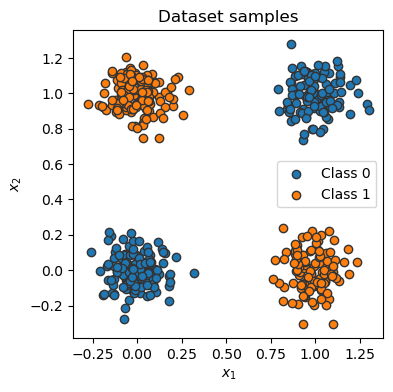

In [41]:
dataset = XORDataset(size=500)
visualize_samples(dataset.data, dataset.label)

データローダークラスは、データセットに対する反復処理を可能にし、自動バッチ処理、マルチプロセスデータロードなど、多くの機能をサポートしている。

- `batch_size`: バッチごとにスタックするサンプルの数
- `shuffle`: ランダムにサンプリングを行う
- `num_workers`: データ読み込みに使用するサブプロセスの数。デフォルトの0は、データがメインプロセスで読み込まれることを意味する
- `pin_memory`: データローダーはテンソルを返す前に CUDAの固定メモリにコピーし、GPU上の大きなデータポイントの処理時間を短縮
- `drop_last`: 最後のバッチが指定されたバッチサイズより小さい場合は削除

In [42]:
from torch.utils.data import DataLoader

data_loader = DataLoader(dataset, batch_size=8, shuffle=True)
# 1つ目のバッチを取り出す
data_inputs, data_labels = next(iter(data_loader))
print("Data inputs", data_inputs.shape, "\n", data_inputs)
print("Data labels", data_labels.shape, "\n", data_labels)

Data inputs torch.Size([8, 2]) 
 tensor([[ 0.9377, -0.0786],
        [ 0.0982,  0.0055],
        [ 0.9355,  0.7679],
        [-0.0103,  1.0979],
        [ 1.0104,  0.9964],
        [ 0.0660,  0.0274],
        [ 0.0326,  0.0483],
        [-0.0243,  0.9137]])
Data labels torch.Size([8]) 
 tensor([1, 0, 0, 1, 0, 0, 0, 1])


モデルとデータセットを定義したら、モデルの最適化を行う。

1. データローダーからバッチを取得
2. バッチのモデルから予測を取得
3. 予測とラベルの差に基づいて損失を計算
4. 損失に関する各パラメタの勾配を計算してバックプロパゲーション
5. モデルのパラメータを勾配の方向に更新

繰り返すことで最適化していく。

パラメタを更新するために、PyTorchは一般的な最適化手法を実装したパッケージを提供している。

- SDG: 確率的勾配降下法は、データ全体の勾配の代わりに、ランダムに選んだ 1サンプル/ミニバッチ から勾配を推定して更新する勾配降下法。
- Momentum: 勾配の慣性を蓄積し、その“慣性”で更新方向を安定化・加速する手法（SGD の拡張）。
- Adam: 勾配の1次（平均）と2次（分散/二乗平均）の移動平均を用いて、各パラメータごとに更新幅を適応的に調整する最適化手法。

`optimizer.step()`、`optimizer.zero_grad()`という2つの便利な関数が提供されている。`optimizer.step()`は、勾配に基づいてパラメタを更新する関数で、`optimizer.zero_grad()`はすべてのパラメタの勾配を0に初期化する。backwardの前のバッチからのパラメータ勾配が0以外のときに損失に対して関数を呼び出すと、新しい勾配は以前の勾配を上書きするのではなく、実際には以前の勾配に追加されることになる。

今回はXORデータセットなので、損失関数はバイナリクロスエントロピーを使用する。

$$
\mathcal{L}_{BCE} = -\sum_i \left[ y_i \log x_i + (1 - y_i) \log (1 - x_i) \right]
$$

`BCEWithLogitsLoss`は、シグモイド層とBCE損失を1つのクラスに統合したもので。損失関数に対数を適用しているため、単純なシグモイド層にBCE損失を適用するよりも数値的に安定している。この場合、モデルの出力にシグモイドを適用する必要はない。

データセット、モデル、最適化手法、損失関数の定義も完了したので学習を行う。

In [43]:
from tqdm import tqdm

# ここではCPUを利用
device = torch.device("cpu")
model.to(device)


def train_model(model, optimizer, data_loader, loss_module, num_epochs=100):
    # Set model to train mode
    model.train()

    # Training loop
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            preds = model(data_inputs)
            preds = preds.squeeze(dim=1)
            loss = loss_module(preds, data_labels.float())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

In [44]:
train_dataset = XORDataset(size=1000)
train_data_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [45]:
train_model(
    model=SimpleClassifier(),
    optimizer=torch.optim.SGD(model.parameters(), lr=0.1),
    data_loader=train_data_loader,
    loss_module=nn.BCEWithLogitsLoss(),
    num_epochs=1000,
)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:03<00:00, 272.34it/s]


モデルの学習が完了したら、同じ重みをロードできるように、モデルを保存できる。`state_dict`モデルから、学習可能なすべてのパラメータを含む、状態辞書を抽出しておく。

In [46]:
state_dict = model.state_dict()
torch.save(state_dict, "nn_model.tar")
print(state_dict)

OrderedDict([('linear1.weight', tensor([[ 0.3500, -0.1891],
        [-0.0359, -0.5133],
        [ 0.2140, -0.4281],
        [ 0.0450,  0.2186]])), ('linear1.bias', tensor([-0.4683, -0.3284, -0.2563,  0.1667])), ('linear2.weight', tensor([[ 0.0409, -0.2234, -0.3503, -0.2055]])), ('linear2.bias', tensor([-0.4500]))])


書き出したモデルの状態辞書を利用することで学習済みモデルを再現できる。

In [47]:
state_dict = torch.load("./nn_model.tar")
new_model = SimpleClassifier(num_inputs=2, num_hidden=4, num_outputs=1)
new_model.load_state_dict(state_dict)
print("Original model\n", model.state_dict())
print("\nLoaded model\n", new_model.state_dict())

Original model
 OrderedDict([('linear1.weight', tensor([[ 0.3500, -0.1891],
        [-0.0359, -0.5133],
        [ 0.2140, -0.4281],
        [ 0.0450,  0.2186]])), ('linear1.bias', tensor([-0.4683, -0.3284, -0.2563,  0.1667])), ('linear2.weight', tensor([[ 0.0409, -0.2234, -0.3503, -0.2055]])), ('linear2.bias', tensor([-0.4500]))])

Loaded model
 OrderedDict([('linear1.weight', tensor([[ 0.3500, -0.1891],
        [-0.0359, -0.5133],
        [ 0.2140, -0.4281],
        [ 0.0450,  0.2186]])), ('linear1.bias', tensor([-0.4683, -0.3284, -0.2563,  0.1667])), ('linear2.weight', tensor([[ 0.0409, -0.2234, -0.3503, -0.2055]])), ('linear2.bias', tensor([-0.4500]))])


/var/folders/s7/r__8fgpd56l0s3kgg97276280000gn/T/ipykernel_23206/716949182.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("./nn_model.tar")


テストデータを生成して、評価を行う。

In [48]:
def eval_model(model, data_loader):
    model.eval()
    true_preds, num_preds = 0.0, 0.0

    with torch.no_grad():
        for data_inputs, data_labels in data_loader:
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1)
            preds = torch.sigmoid(preds)
            pred_labels = (preds >= 0.5).long()

            true_preds += (pred_labels == data_labels).sum()
            num_preds += data_labels.shape[0]

    acc = true_preds / num_preds
    print(f"Accuracy of the model: {100.0 * acc:4.2f}%")


test_dataset = XORDataset(size=500)
test_data_loader = DataLoader(
    test_dataset, batch_size=128, shuffle=False, drop_last=False
)
eval_model(model, test_data_loader)

Accuracy of the model: 51.80%


最後に、線形回帰で取り扱う問題をPytorchでニューラルネットワークを学習させて解いてみる。

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [50]:
# データの生成
torch.manual_seed(1989)
a = 2
b = 10
n = 100
x = torch.linspace(-10, 10, n).view(n, 1)
x.size()

torch.Size([100, 1])

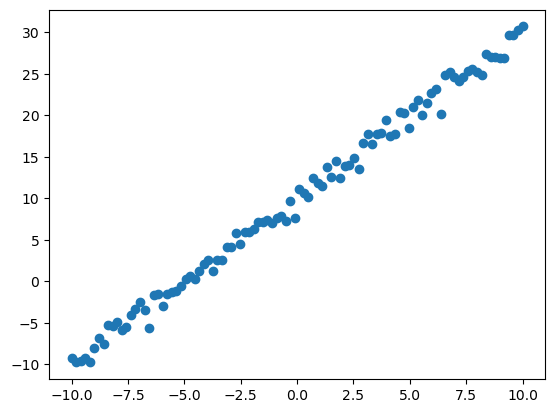

In [51]:
eps = torch.randn(n, 1)
y = a * x + b + eps
plt.scatter(x, y)

`in_features=1`となるのは特徴量が1つだからであり、サンプルサイズの数だけ増えるわけではなく、特徴量の数に比例する。`[1,2,3]`のようなtensorの場合、特徴量は3つで、サンプルサイズは1つである。


In [52]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear(x)

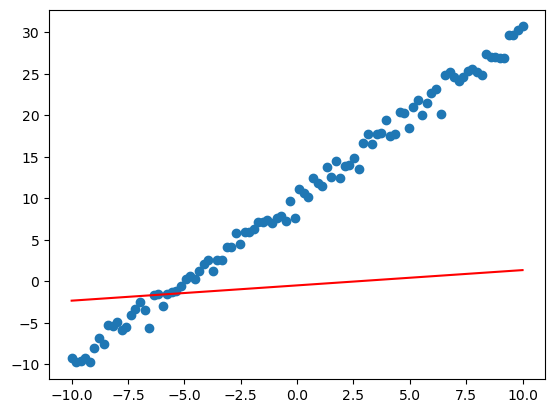

In [53]:
model = LinearRegression()
x_pred = torch.linspace(-10, 10, n).view(n, 1)
y_pred = model(x_pred)
plt.scatter(x, y)
plt.plot(x_pred, y_pred.detach(), "r-")

順伝搬を1回実行しただけでは役に立つ予測ができない。

epoch: 0, loss: 223.2467041015625
epoch: 100, loss: 74.71654510498047
epoch: 200, loss: 50.351531982421875
epoch: 300, loss: 34.025794982910156
epoch: 400, loss: 23.086713790893555
epoch: 500, loss: 15.75695514678955
epoch: 600, loss: 10.845646858215332
epoch: 700, loss: 7.554805755615234
epoch: 800, loss: 5.349780082702637
epoch: 900, loss: 3.8723065853118896
epoch: 1000, loss: 2.882315158843994
epoch: 1100, loss: 2.218970537185669
epoch: 1200, loss: 1.7744897603988647
epoch: 1300, loss: 1.4766672849655151
epoch: 1400, loss: 1.277108907699585
epoch: 1500, loss: 1.1433976888656616
epoch: 1600, loss: 1.0537995100021362
epoch: 1700, loss: 0.993765115737915
epoch: 1800, loss: 0.9535403251647949
epoch: 1900, loss: 0.9265840649604797


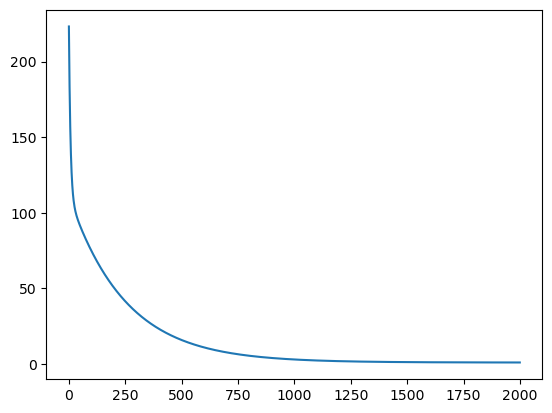

In [54]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)
losses = []
for epoch in range(2000):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred, y)
    loss.backward()
    losses.append(loss.item())
    optimizer.step()
    if epoch % 100 == 0:
        print(f"epoch: {epoch}, loss: {loss.item()}")
plt.plot(losses)

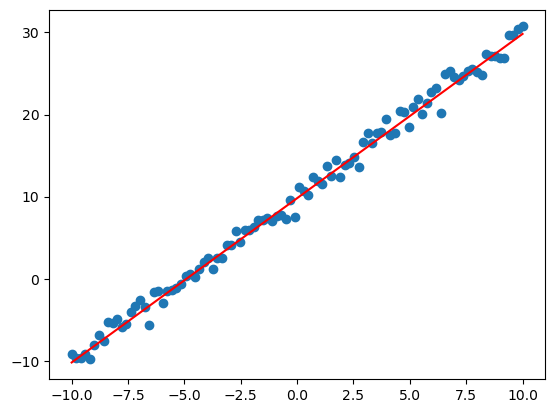

In [55]:
x_pred = torch.linspace(-10, 10, n).view(n, 1)
y_pred = model(x_pred)
plt.scatter(x, y)
plt.plot(x_pred, y_pred.detach(), "r-")